In [1]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Linguistic Confidence",
    "dist_semantic_uncertainty": "Dist. Semantic Uncertainty",
    "dist_lnll": "Dist. Token Probability"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "trivia_qa": "TriviaQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
calibration_mode = "univariate"
results_dir = f"/hdd/ivny/in_domain_{calibration_mode}_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in tqdm(leaf_dirs):
    _, _, _, _, dataset_name, estimation_method, _, model_name = leaf_dir.split("/")
    csv_data = pd.read_csv(os.path.join(leaf_dir, "linguistic_calibration_outputs.csv"))[["calibrated_numerical_confidence", "calibrated_linguistic_confidence"]]
    # use re to extract mu after "mu=" and before ", sigma"
    signal_alpha = csv_data["calibrated_numerical_confidence"].apply(lambda x: float(re.search(r"alpha=([0-9\.]+)", x).group(1)) if re.search(r"alpha=([0-9\.]+)", x) else np.nan).tolist()
    linguistic_alpha = csv_data["calibrated_linguistic_confidence"].apply(lambda x: float(re.search(r"alpha=([0-9\.]+)", x).group(1)) if re.search(r"alpha=([0-9\.]+)", x) else np.nan).tolist()
    signal_beta = csv_data["calibrated_numerical_confidence"].apply(lambda x: float(re.search(r"beta=([0-9\.]+)", x).group(1)) if re.search(r"beta=([0-9\.]+)", x) else np.nan).tolist()
    linguistic_beta = csv_data["calibrated_linguistic_confidence"].apply(lambda x: float(re.search(r"beta=([0-9\.]+)", x).group(1)) if re.search(r"beta=([0-9\.]+)", x) else np.nan).tolist()
    df_dict = {
        "Dataset": dataset_map[dataset_name],
        "Est. Method": methods_names[estimation_method],
        "Model": model_name_map[model_name],
        "signal_alpha": signal_alpha,
        "linguistic_alpha": linguistic_alpha,
        "signal_beta": signal_beta,
        "linguistic_beta": linguistic_beta
    }
    all_records.append(df_dict)

full_df = pd.DataFrame(all_records)

100%|██████████| 54/54 [00:09<00:00,  5.65it/s]


In [4]:
full_df.head()

,Dataset,Est. Method,Model,signal_alpha,linguistic_alpha,signal_beta,linguistic_beta
0,MMLU,Dist. Linguistic Confidence,Llama-3.1-8B-Inst.,"[29.648465971998153, 8.067877650499229, 11.179...","[6.170476076268144, 16.284304932735452, 0.7222...","[9.246039465269144, 3.2918602981244924, 8.0918...","[1.015637366590721, 1.9443946188340888, 0.5798..."
1,MMLU,Dist. Linguistic Confidence,Llama-3-8B-Inst.,"[7.87859320862636, 6.931106701945532, 11.32683...","[9.408727272727274, 3.2297368234627375, 3.9369...","[4.169255528733408, 4.771620445935066, 5.81190...","[4.427636363636365, 2.135274511192972, 2.10747..."
2,MMLU,Dist. Linguistic Confidence,Qwen2.5-7B-Inst.,"[85.44806201669154, 8.911962152997747, 6.94377...","[3.7895245335984575, 5.674634705814889, 2.9839...","[26.41698167207045, 3.1511952343943768, 4.2755...","[1.1879595297970655, 2.6216148640899215, 1.981..."
3,MMLU,Dist. Linguistic Confidence,Qwen3-8B-Inst.,"[0.5689195428766048, 5.299075736416017, 36.663...","[8.60728319096572, 17.5982693649686, 1.5354841...","[0.30787212518133555, 1.4932934182320348, 8.86...","[0.6213978572462768, 5.803684577808797, 0.4543..."
4,MMLU,Dist. Linguistic Confidence,Mistral-7B-Inst.,"[0.7049981955694471, 7.49787169339361, 5.44500...","[3.4991595994686837, 8.471094463078023, 1.5124...","[0.740890919320321, 5.623733042211392, 4.23486...","[13.93851282313273, 3.9741961291032064, 3.1991..."


In [5]:
from scipy.stats import wasserstein_distance, beta, spearmanr
import numpy as np

# Prepare lists to store distances
wasserstein_list = []
signal_means = []
linguistic_means = []

for (idx, row) in tqdm(list(full_df.iterrows())):
    
    signal_alpha = np.array(row['signal_alpha'])
    signal_beta = np.array(row['signal_beta'])
    linguistic_alpha = np.array(row['linguistic_alpha'])
    linguistic_beta = np.array(row['linguistic_beta'])

    signal_mu = signal_alpha / (signal_alpha + signal_beta)
    linguistic_mu = linguistic_alpha / (linguistic_alpha + linguistic_beta)

    # Sample from the Beta distributions
    linguistic_dist = [beta.rvs(a, b, size=1000) for a, b in zip(linguistic_alpha, linguistic_beta)]
    signal_dist = [beta.rvs(a, b, size=1000) for a, b in zip(signal_alpha, signal_beta)]
    
    # Skip if lengths mismatch
    if len(signal_alpha) != len(linguistic_dist):
        continue

    # Compute Wasserstein distance for each sentence
    distances = [wasserstein_distance(s, l) for s, l in zip(signal_dist, linguistic_dist)]
    
    # Store mean distance for this row (estimation method / model)
    wasserstein_list.extend(distances)

    # Store means for this row
    signal_means.extend(signal_mu)
    linguistic_means.extend(linguistic_mu)

100%|██████████| 54/54 [04:31<00:00,  5.02s/it]


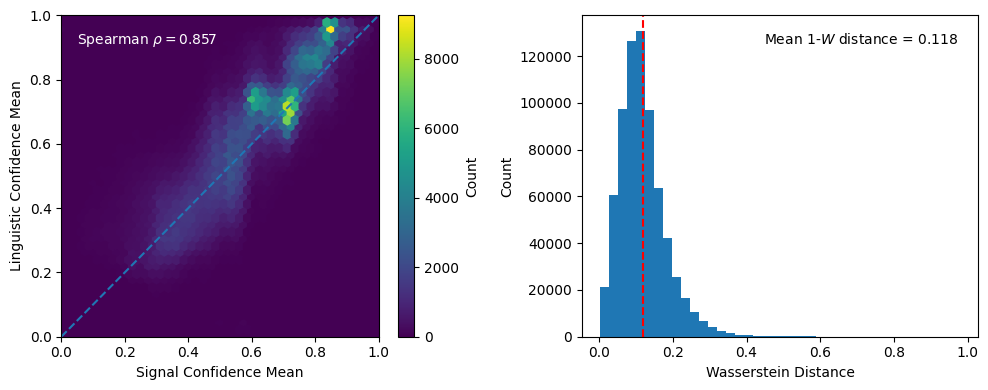

In [8]:
mean_w = np.mean(wasserstein_list)
rho = spearmanr(signal_means, linguistic_means)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: Hexbin ----
hb = axes[0].hexbin(
    signal_means,
    linguistic_means,
    gridsize=40,
    extent=(0,1,0,1)
)

axes[0].plot([0,1],[0,1], linestyle='--')
axes[0].set_xlabel("Signal Confidence Mean")
axes[0].set_ylabel("Linguistic Confidence Mean")
# axes[0].set_title("Signal → Linguistic Alignment (Density)")
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)

# Overlay Spearman
axes[0].text(
    0.05, 0.95,
    rf"Spearman $\rho = {rho:.3f}$",
    transform=axes[0].transAxes,
    verticalalignment='top',
    color='white',
)

cb = fig.colorbar(hb, ax=axes[0])
cb.set_label("Count")

# ---- Right: Wasserstein Histogram ----
axes[1].hist(wasserstein_list, bins=40)
axes[1].axvline(mean_w, linestyle='--', color='red', label=f"Mean = {mean_w:.3f}")
axes[1].set_xlabel("Wasserstein Distance")
axes[1].set_ylabel("Count")
# axes[1].set_title("Distributional Shift per Sentence")

# Overlay mean Wasserstein
axes[1].text(
    0.95, 0.95,
    rf"Mean 1-$W$ distance = {mean_w:.3f}",
    transform=axes[1].transAxes,
    horizontalalignment='right',
    verticalalignment='top'
)

plt.tight_layout()
plt.savefig("signal_linguistic_confidence_alignment.pdf", dpi=300, bbox_inches='tight')